In [ ]:
Country-data

In [2]:
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
import pandas as pd

country_data = pd.read_csv('Country-data.csv')

# Display the first few rows of the dataset to understand its structure
country_data.head()

,Country,Child_Mort,Exports,Health,Imports,Income,Inflation,Life_Expec,Total_Fer,GDPP
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [6]:
# Dropping the 'country' column for clustering
data_for_clustering = country_data.drop('Country', axis=1)

# Standardizing the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_for_clustering)

# Applying agglomerative hierarchical clustering
linkage_matrix = linkage(data_scaled, method='ward')

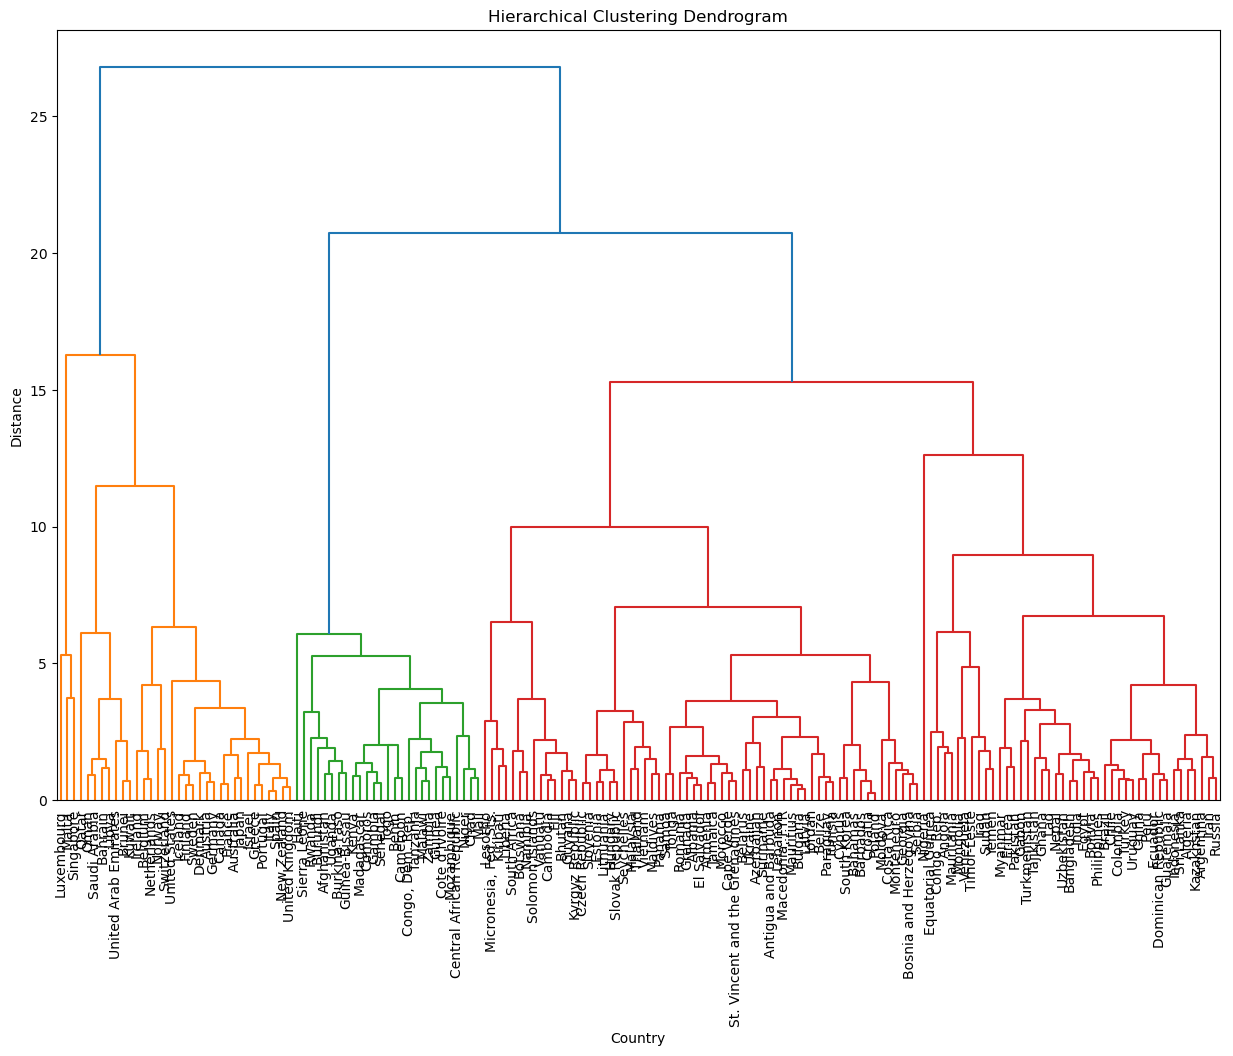

In [10]:
# Plotting the dendrogram
plt.figure(figsize=(15, 10))

dendrogram(
    linkage_matrix,
    labels=country_data['Country'].values,
    leaf_rotation=90,
    leaf_font_size=10
)

plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Country')
plt.ylabel('Distance')
plt.show()

In [14]:
from scipy.cluster.hierarchy import fcluster

# Let's analyze the data at two clusters

# Assigning countries to 2 clusters  (First Cut)
clusters_2 = fcluster(linkage_matrix, t=2, criterion='maxclust')

# Adding cluster labels to the original dataframe
country_data['Cluster_2'] = clusters_2

# Calculating the mean of all NUMERIC features for each cluster
mean_features_2 = country_data.groupby('Cluster_2').mean(numeric_only=True)

# Displaying the cluster-wise mean values
print(mean_features_2)

           Child_Mort    Exports    Health    Imports        Income  \
Cluster_2                                                             
1            5.961765  58.508824  8.501176  48.902941  47588.235294   
2           46.529323  36.660895  6.384812  46.375683   9362.127820   

           Inflation  Life_Expec  Total_Fer          GDPP  
Cluster_2                                                  
1            4.11550   79.982353   1.888529  43170.588235  
2            8.71909   68.145865   3.218797   5242.210526  


In [18]:
from scipy.cluster.hierarchy import fcluster

# Let's analyze the data at 3 clusters

# Assigning countries to 3 clusters  ( 2 Cut)  Cluster_1-> Pink , Cluster_2-> Green , Cluster_3-> red
clusters_3 = fcluster(linkage_matrix, t=3, criterion='maxclust')

# Adding cluster labels to the original dataframe
country_data['Cluster_3'] = clusters_3

# Calculating the mean of all NUMERIC features for each cluster
mean_features_3 = country_data.groupby('Cluster_3').mean(numeric_only=True)

# Displaying the cluster-wise mean values
print(mean_features_3)

           Child_Mort    Exports    Health    Imports        Income  \
Cluster_3                                                             
1            5.961765  58.508824  8.501176  48.902941  47588.235294   
2          105.070370  23.589630  6.507037  39.662963   1589.740741   
3           31.617925  39.990368  6.353679  48.085527  11341.886792   

           Inflation  Life_Expec  Total_Fer          GDPP  Cluster_2  
Cluster_3                                                             
1           4.115500   79.982353   1.888529  43170.588235        1.0  
2           7.142778   57.248148   5.433704    667.888889        2.0  
3           9.120604   70.921698   2.654623   6407.367925        3.0  


In [20]:
from scipy.cluster.hierarchy import fcluster

# Let's analyze the data at two clusters

# Assigning countries to 4 clusters  (3  Cut)  Cluster_1-> Pink , Cluster_2-> Pink ,Cluster_3-> Green, Cluster_4-> red
clusters_4 = fcluster(linkage_matrix, t=4, criterion='maxclust')

# Adding cluster labels to the original dataframe
country_data['Cluster_4'] = clusters_4

# Calculating the mean of all NUMERIC features for each cluster
mean_features_4 = country_data.groupby('Cluster_4').mean(numeric_only=True)

# Displaying the cluster-wise mean values
print(mean_features_4)

           Child_Mort     Exports    Health     Imports        Income  \
Cluster_4                                                               
1            4.133333  176.000000  6.793333  156.666667  64033.333333   
2            6.138710   47.138710  8.666452   38.474194  45996.774194   
3          105.070370   23.589630  6.507037   39.662963   1589.740741   
4           31.617925   39.990368  6.353679   48.085527  11341.886792   

           Inflation  Life_Expec  Total_Fer          GDPP  Cluster_2  \
Cluster_4                                                              
1           2.468000   81.433333   1.380000  57566.666667        1.0   
2           4.274935   79.841935   1.937742  41777.419355        1.0   
3           7.142778   57.248148   5.433704    667.888889        2.0   
4           9.120604   70.921698   2.654623   6407.367925        3.0   

           Cluster_3  
Cluster_4             
1                1.0  
2                1.0  
3                2.0  
4            

### Cluster 1: The Elite Economies

- **In Cluster 1**, we find the pinnacle of global economic and social success. These are the elite economies, where affluence is the norm. The average income soars at around 64,033, and the GDP per capita is an impressive 57,567. These countries are deeply integrated into the global market, evident from their exceptionally high exports (176% of GDP) and imports (156.67%) rates, possibly indicating a strong focus on trade and services.

- Healthcare here is more than adequate, though not the highest in spending, suggesting efficient systems. The child mortality rate is incredibly low (about 4.13 deaths per 1,000 births), and life expectancy is the highest among all clusters, at 81.43 years. The fertility rate is low (1.38), reflecting stable population growth and access to reproductive health services. The economies are remarkably stable, with an inflation rate of just 2.47%.

### Cluster 2: The Comfortable Middle

- **Cluster 2** countries enjoy comfortable economic conditions, though not as affluent as Cluster 1. These nations have a healthy average income of 45,997 and a high GDP per capita of 41,777. They engage significantly in international trade, though to a lesser extent than Cluster 1.
- Their health spending is the highest among all clusters, averaging 8.67% of GDP, which correlates with good healthcare outcomes—a low child mortality rate (6.14) and high life expectancy (79.84 years). The total fertility rate is moderately low (1.94), and inflation is reasonably controlled at 4.27%.

### Cluster 3: The Struggling States

- **Cluster 3** represents the struggling states, grappling with numerous socio-economic challenges. The average income here plummets to 1,589, and the GDP per capita is a mere 667.89, indicating severe economic constraints. Trade is limited, reflecting perhaps a reliance on primary sectors or challenges in integrating with global markets.

- The health scenario is dire, with the highest child mortality rate at 105.07 and the lowest life expectancy at 57.25 years. Health spending, while not the lowest, fails to meet the vast needs. The fertility rate is high (5.43), suggesting limited access to or knowledge of family planning. Inflation is moderately high at 7.14%, further straining the economic conditions.

### Cluster 4: The Developing Dynamic

- Finally, **Cluster 4** captures the essence of dynamic developing countries. These nations have a moderate income level (11,341) and GDP per capita (6,407). Their trade levels are balanced, suggesting a growing engagement with the global market.

- Healthcare spending is relatively lower (6.35% of GDP), which, coupled with other socio-economic factors, results in a moderate child mortality rate (31.62) and life expectancy (70.92 years). The fertility rate of 2.65 indicates a transitioning demographic profile. However, these countries face economic challenges, evident from the highest inflation rate among the clusters (9.12%).